# Mathematische OSS in der Praxis
**Logik, Optimierung, Graphentheorie und mehr mit SageMath**

**Manfred Scheucher**  
Grazer Linuxtage 2026

<img src="figs/arrangement.png" width="30%">

Slides: <a href="https://github.com/manfredscheucher/talk-glt26">https://github.com/manfredscheucher/talk-glt26</a>

---
# Was erwartet mich in diesem Vortrag?

* Slides in Jupyter Notebook — Markdown und Code gemischt
  * sonst LaTeX Beamer oder [IPE Drawing Editor](https://ipe.otfried.org/) (Vektorgrafiken oder ganze Slides)
* viele Beispiele
* schöne Bilder
* Code-Snippets in Python-Syntax
* Python-Kenntnisse hilfreich, aber nicht notwendig

---
# SageMath 

* Freie Software zur Lösung mathematischer Probleme
* vereint Stärken vieler Open-Source-Libraries
  * **PARI/GP, FLINT, NTL** — Zahlentheorie (elliptische Kurven, Polynome, Gitter)
  * **GAP, Singular** — Gruppen- und Ringtheorie, Gröbner-Basen
  * **Maxima, SymPy** — symbolische Algebra, Analysis
  * **GLPK** — lineare/ganzzahlige Optimierung (LP/IP/MILP)
  * **NumPy/SciPy** — numerisch
  * **NetworkX, Boost, Nauty** — Graphen, Automorphismen
  * **Matplotlib, Three.js, Jmol** — 2D/3D-Plots
  * ...
* einheitliches Python-Interface
  * große Teile in Cython (Performance, C/C++-Anbindung)
  * auch R, Octave, Mathematica, ... nutzbar
* 150+ Seiten Dokumentation mit Beispielen
    * [https://doc.sagemath.org/](https://doc.sagemath.org/)
* Installation: conda-forge, pip (Modularisierung in Arbeit)
    * [https://doc.sagemath.org/html/en/installation/](https://doc.sagemath.org/html/en/installation/)

---
## Warum nicht einfach C/C++ oder Python?

**C/C++ — Integer Overflow:**
```c
int x = 1;
for (int i = 0; i < 100; i++) x *= 2;
// → 0  (Overflow!)
```

**C++ mit GMP** (GNU Multiple Precision Arithmetic Library) — beliebig große Ganzzahlen:
```c
#include <gmpxx.h>
mpz_class x = 1;
for (int i = 0; i < 100; i++) x *= 2;
// → 1267650600228229401496703205376
```

**Python** — big integers out of the box:
```python
2**100  # → 1267650600228229401496703205376
```

**Aber — Gleitkomma:**
```c
#include <cmath>
float  x = sqrt(2.0f); printf("%.20f\n", x*x); // → 1.99999988079071044922
double x = sqrt(2.0);  printf("%.20f\n", x*x); // → 2.00000000000000044409
```

```python
import math
x = math.sqrt(2.0)
print(x*x)  # → 2.0000000000000004
```


Irrationale Zahlen sind zwar nicht in Floats darstellbar — aber hier wirds spannend!

## Irrationale Zahlen: Algebraisch vs. Transzendent

**Algebraische Zahlen** — Nullstellen von Polynomen mit ganzzahligen Koeffizienten:
- $\sqrt{2}$: Nullstelle von $x^2 - 2$
- $\sqrt[3]{5}$: Nullstelle von $x^3 - 5$
- $\sqrt{2}+1$: Nullstelle von $(x-1)^2 - 2=(x^2-2x+1)-2=x^2-2x-1$

Durch Repräsentation als Polynom ist **exaktes Rechnen** möglich!

**Beispiel:**
```python
sqrt(6) / sqrt(2)   # → sqrt(3)
```

Intern: $z = x/y$ mit $x^2 = 6$, $y^2 = 2$ $\;\Rightarrow\;$ $z^2 = x^2/y^2 = 6/2 = 3$, also Minimalpolynom $z^2 - 3$.

**Komplizierteres Beispiel:** $x = \sqrt{2}+\sqrt{3}$

$$\begin{align}
x - \sqrt{2} &= \sqrt{3} \\
(x-\sqrt{2})^2 &= 3 \\
x^2 - 2x\sqrt{2} + 2 &= 3 \\
x^2 - 1 &= 2x\sqrt{2} \\
(x^2-1)^2 &= 8x^2 \\
x^4 - 10x^2 + 1 &= 0
\end{align}$$

```python
(sqrt(2)+sqrt(3)).minpoly()  # → x^4 - 10*x^2 + 1
```


**Transzendente Zahlen** — kein solches Polynom existiert für $\pi$, $e$, $\sin(1)$, ...

- aber: bekannte Identitäten sind in Sage symbolisch vorhanden:
```python
sin(pi)    # → 0
sin(pi/2)  # → 1
```
- Sage erkennt sogar Grenzwerte/Folgen/Reihen und formt um!
```python
n = var('n')
limit((1 + 1/n)^n, n=oo)  # → e
```

```python
n, x = var('n x')
sum(x^n / factorial(n), n, 0, oo)  # → e^x
```

*Anmerkung*: Kommerzielle Tools wie Wolfram Mathematica/Alpha können das natürlich auch — aber Sage ist OSS: wer will, kann bis ganz unten lesen und alles verstehen.

---
# Basics

Wie verwendet man "sage"?
* Jupyter Notebook `sage --notebook` oder `sage -n` # <-- im gesamten talk!
* CommandLineInterface `sage`
* Script mit Parameter `sage script.sage`

In [1]:
print("Hallo Welt!") # Python Input/Output
print("Hallo Graz!")

Hallo Welt!
Hallo Graz!


In [2]:
"Hallo Welt!" 
"Hallo Graz!" # Jupyter Notebook zeigt letztes an

'Hallo Graz!'

In [3]:
def f(x): return x*x
print([f(x) for x in range(10)]) # Funktionen, List Comprehension, etc.

[0, 1, 4, 9, 16, 25, 36, 49, 64, 81]


In [4]:
def my_generator():
    s = 'hallo'
    while True:
        yield s
        s += 'X'

g = my_generator()
for i in range(10): print(i,next(g)) # Generatoren

0 hallo
1 halloX
2 halloXX
3 halloXXX
4 halloXXXX
5 halloXXXXX
6 halloXXXXXX
7 halloXXXXXXX
8 halloXXXXXXXX
9 halloXXXXXXXXX


**Übersicht über Objekte und Methoden**

In [5]:
G=Graph()
G?

Type:        Graph
String form: Graph on 0 vertices
Length:      0
File:        /var/tmp/sage-10.8-current/local/lib/python3.13/site-packages/sage/graphs/graph.py
Docstring:  
Undirected graph.

A graph is a set of vertices connected by edges. See the
https://en.wikipedia.org/wiki/Graph_(mathematics) for more
information. For a collection of pre-defined graphs, see the
"graph_generators" module.

A "Graph" object has many methods whose list can be obtained by typing
"g.<tab>" (i.e. hit the "Tab" key) or by reading the documentation of
"graph", "generic_graph", and "digraph".

INPUT:

By default, a "Graph" object is simple (i.e. no *loops* nor *multiple
edges*) and unweighted. This can be easily tuned with the appropriate
flags (see below).

* "data" -- can be any of the following (see the "format" argument):

  1. "Graph()" -- build a graph on 0 vertices.

  2. "Graph(5)" -- return an edgeless graph on the 5 vertices 0,...,4.

  3. "Graph([list_of_vertices, list_of_edges])" -- returns 

In [6]:
#G.<tabulator>     ->  Liste von Attributen und Methoden
G.is_connected?

Signature:      G.is_connected(G, forbidden_vertices=None)
Docstring:     
Check whether the (di)graph is connected.

Note that in a graph, path connected is equivalent to connected.

INPUT:

* "G" -- the input graph

* "forbidden_vertices" -- list (default: "None"); set of vertices to
  avoid during the search

See also:

  * "is_biconnected()"

EXAMPLES:

   sage: from sage.graphs.connectivity import is_connected
   sage: G = Graph({0: [1, 2], 1: [2], 3: [4, 5], 4: [5]})
   sage: is_connected(G)
   False
   sage: G.is_connected()
   False
   sage: G.add_edge(0,3)
   sage: is_connected(G)
   True
   sage: is_connected(G, forbidden_vertices=[3])
   False
   sage: is_connected(G, forbidden_vertices=[1])
   True
   sage: D = DiGraph({0: [1, 2], 1: [2], 3: [4, 5], 4: [5]})
   sage: is_connected(D)
   False
   sage: D.add_edge(0, 3)
   sage: is_connected(D)
   True
   sage: D = DiGraph({1: [0], 2: [0]})
   sage: is_connected(D)
   True
Init docstring: Initialize self.  See help(type(self))

**Zeit messen in Jupyter**

In [7]:
%%time 
def fib(x): return x if x<=1 else fib(x-1)+fib(x-2)
print([fib(x) for x in range(32)]) 

[0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610, 987, 1597, 2584, 4181, 6765, 10946, 17711, 28657, 46368, 75025, 121393, 196418, 317811, 514229, 832040, 1346269]
CPU times: user 3.55 s, sys: 11.2 ms, total: 3.56 s
Wall time: 3.56 s


In [8]:
%%time
@cached_function 
def fib(x): return x if x<=1 else fib(x-1)+fib(x-2)
print([fib(x) for x in range(32)]) # Dynamische Programmierung: Zwischenergebnisse speichern

[0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610, 987, 1597, 2584, 4181, 6765, 10946, 17711, 28657, 46368, 75025, 121393, 196418, 317811, 514229, 832040, 1346269]
CPU times: user 225 μs, sys: 11 μs, total: 236 μs
Wall time: 234 μs


**Command-Line Parameter**
* Ausführung auch via commandline: `sage script.sage` bzw `time sage script.sage`
* Parameter `argv` bzw `argparse`

```python
# https://docs.python.org/3/library/argparse.html
parser.add_argument('filename') # mandatory filename
parser.add_argument('-c', '--count', type=int) # optional integer
parser.add_argument('-v', '--verbose', action='store_true') # optional flag
```

**Multithreading**

In [9]:
%%time 
import time
def f(i): 
    time.sleep(float(0.1)) 
    return i
print([f(i) for i in range(50)]) # 5 Sekunden auf 1 CPU (single-threaded)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
CPU times: user 8.9 ms, sys: 2.08 ms, total: 11 ms
Wall time: 5.18 s


In [10]:
%%time 
@parallel
def f(i): 
    time.sleep(float(0.1)) 
    return i
print(list(f(range(50)))) # 0.1 Sekunden (parallelisiert in Jupyter)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
CPU times: user 624 μs, sys: 839 μs, total: 1.46 ms
Wall time: 105 ms


Sideremarks: 
* in diesem Beispiel braucht selbst `print(list(f(range(1000))))` nur 0.1 sec da kein busy wait!
* für Sage-Script `multiprocessing.Pool.map` verwenden, siehe [pool_example.sage](pool_example.sage)

In [11]:
# Zeitmessen und Parallelisierung in CL
!sage pool_example.sage 

22:14:16.069 single-thread start
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
22:14:21.260 single-thread stop
22:14:21.323 parallel start
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
22:14:23.786 parallel stop


---
## Zahlentheorie & Kryptographie

In [12]:
x = 1337
print(x.is_prime())
print(x.factor())
print(next_prime(x))
# Liste von Methoden durch Eingabe von: x.<tabulator>

False
7 * 191
1361


**Modulare Arithmetik** (RSA u.a. Cryptosysteme):

$$2^{12} \mod 17 = \;?$$


In [13]:
power_mod(2, 12, 17)
# 2^12 = 2^(4*3) = (2^4)^3 = 16^3 = (-1)^3 = -1 = 16 mod 17

16

Ausführliche Funktionen und Doku zu **ECC** (Elliptic Curve Cryptography):

<a href="https://doc.sagemath.org/html/en/reference/arithmetic_curves/index.html">https://doc.sagemath.org/html/en/reference/arithmetic_curves/index.html</a>

---
## Kurvendiskussion


Klassische Matura-Aufgaben

In [14]:
# Beispiel 1
x = var('x')
f = 1-x^2
print(f) # Textuelle Ausgabe
f.show() # Formatierte Ausgabe

-x^2 + 1


-x^2 + 1

In [15]:
print("f'(x) =", f.diff()) # Symbolische Ableitung
print("F(x)  =", f.integrate(x)) # Stammfunktion

f'(x) = -2*x
F(x)  = -1/3*x^3 + x


In [16]:
f.roots() # nullstellen mit multiplizitäten

[(-1, 1), (1, 1)]

In [17]:
f.find_local_maximum(-1,1) # numerische suche nach lokalem maximum,  zuerst y wert, dann x wert

(1.0, 4.933333305577758e-09)

In [18]:
f.diff().roots() # extremwerte symbolisch

[(0, 1)]

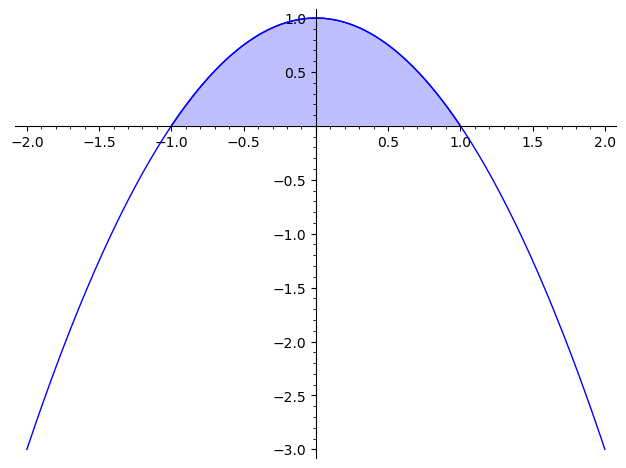

In [19]:
# Plot: Fläche unter Kurve
p  = plot(f, (x, -2, 2))
p += plot(f, (x, -1, 1), fill=True, fillcolor="blue", fillalpha=0.25)
p.show()

In [20]:
# Flächenbestimmung
I = integrate(f, x, -1, 1)
print(f"Fläche: {I} ≈ {float(I)}") # Rechnung symbolisch, Ergebnis numerisch umwandeln

Fläche: 4/3 ≈ 1.3333333333333333


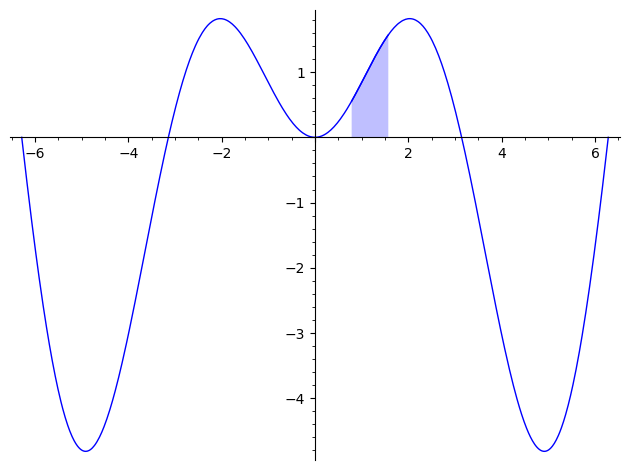

In [21]:
# Beispiel 2: Elementare Funktionen (Sinus, Kosinus,...)
f = x*sin(x)

p  = plot(f, (x, -2*pi, 2*pi))
p += plot(f, (x, pi/4, pi/2), fill=True, fillcolor="blue", fillalpha=0.25)
p.show()

In [22]:
f.find_local_maximum(0,pi) # zuerst y wert, dann x wert

(1.819705741159653, 2.0287578390054044)

In [23]:
# Flächenbestimmung
I = integrate(f, x, pi/4, pi/2)
print(f"Fläche: {I} ≈ {float(I)}") # Rechnung symbolisch, Ergebnis numerisch umwandeln

Fläche: 1/8*sqrt(2)*pi - 1/2*sqrt(2) + 1 ≈ 0.8482535860832482


In [24]:
# beliebige Präzision (Anzahl Bits)
for prec in [30,100,300,1000]:
    R = RealField(prec)
    print(f"{prec} \t-> {R(I)}")

30 	-> 0.84825359
100 	-> 0.84825358608324825647614076165
300 	-> 0.848253586083248256476140761652737673041991773483487241297334581874188109906380719396722100
1000 	-> 0.848253586083248256476140761652737673041991773483487241297334581874188109906380719396722099681774868302919353470197450408082531786867834830224857546409333962203298519505731895261281732387086924235670892379900332787149289022340125581320941646902546785000861569051624975354245554175904560251983112700234


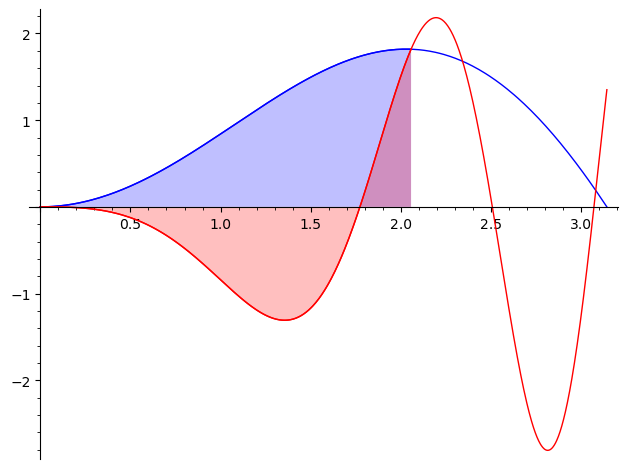

In [25]:
# Plot: Fläche zwischen Kurven 
f = x*sin(x)
g = -x*sin(x*x)

x1 = (f-g).find_root(2,2.3)
p  = plot(f, (x, 0, pi), color='blue')
p += plot(f, (x, 0, x1), color='blue', fill=True, fillcolor='blue', fillalpha=0.25)

p += plot(g, (x, 0, pi), color='red')
p += plot(g, (x, 0, x1), color='red', fill=True, fillcolor='red', fillalpha=0.25)
p.show()

In [26]:
print((f-g).find_root(2,2.3)) # Numerische Suche nach Schnittstellen von f und g
print((f-g).find_root(2.3,3))
print((f-g).find_root(3,3.5))

2.0560096453612196
2.3416277185114787
3.0799958958578673


In [27]:
(f-g).roots() # findet nur x=0 als Nullstelle
# die anderen kommen von der transzendenten Gleichung sin(x)=-sin(x²), kein Polynom, symbolisch nicht lösbar

[(0, 1)]

In [28]:
# Symbolische Flächenbestimmung
I = integrate(f-g, x, pi/4, pi/2)
print(f"Fläche: {I} ≈ {float(I)}")

Fläche: 1/8*sqrt(2)*pi - 1/2*sqrt(2) - 1/2*cos(1/4*pi^2) + 1/2*cos(1/16*pi^2) + 1 ≈ 1.6467117908494968


---
## Gleichungssysteme

**Schnitt von zwei Geraden:** $2x+y=4$, $x+2y=4$:

In [29]:
x, y = var('x y')
solve([2*x+y==4,x+2*y==4],x,y) # (4/3, 4/3)

[[x == (4/3), y == (4/3)]]

Oder etwas umständlicher:
$$A = \begin{pmatrix} 2 & 1 \\ 1 & 2 \end{pmatrix}, \quad b = \begin{pmatrix} 4 \\ 4 \end{pmatrix}, \quad Ax = b \;\Rightarrow\; x = A^{-1} b$$

sol: (4/3, 4/3)


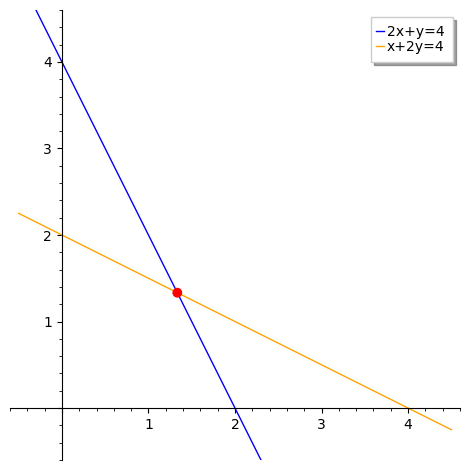

In [30]:
A = matrix([[2,1],[1,2]])
b = vector([4,4])
sol = A.inverse() * b # (4/3, 4/3)
print(f"sol: {sol}")

x = var('x')
p  = plot(4 - 2*x, (x, -0.5, 3), color='blue',   legend_label='2x+y=4')
p += plot(2 - x/2, (x, -0.5, 4.5), color='orange', legend_label='x+2y=4')
p += point(sol, size=50, color='red', zorder=5)
p.show(aspect_ratio=1, xmin=-0.5, xmax=4.5, ymin=-0.5, ymax=4.5)

**Schnitt von zwei Kreisen:**

$$C_1: (x-1)^2 + y^2 = 4 \qquad C_2: (x+1)^2 + y^2 = 4$$

In [31]:
x, y = var('x y')
C1 = (x-1)^2 + y^2 == 4
C2 = (x+1)^2 + y^2 == 4

In [32]:
solutions = solve([C1, C2], x, y) # Symbolische Schnittpunkte
print(solutions)

[
[x == 0, y == -sqrt(3)],
[x == 0, y == sqrt(3)]
]


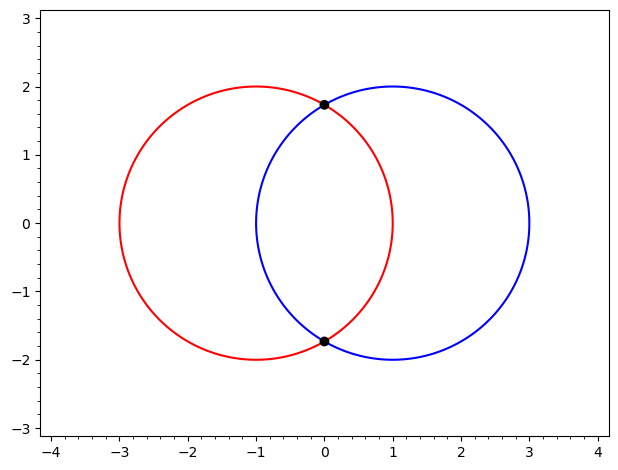

In [33]:
p  = implicit_plot(C1.lhs() - C1.rhs(), (x, -4, 4), (y, -3, 3), color='blue')
p += implicit_plot(C2.lhs() - C2.rhs(), (x, -4, 4), (y, -3, 3), color='red')
for s in solutions:
    sx = s[0].rhs()
    sy = s[1].rhs()
    p += point((RR(sx), RR(sy)), size=50, color='black', zorder=2)
p.show(aspect_ratio=1)

**Idee hinter symbolischen Lösung:**

In [34]:
# jeder Schnittpunkt (x,y) ist Nullstelle beider Gleichungen 
f1 = (x-1)^2 + y^2 - 4 
f2 = (x+1)^2 + y^2 - 4 

In [35]:
# ... und Nullestelle von f3 = f1-f2
f3 = (f1-f2)
print(f3) 
print(f3.simplify_full()) # 4x ist nur Null wenn x=0 

-(x + 1)^2 + (x - 1)^2
-4*x


In [36]:
# ... und Nullstelle von f4 = f1+f2, insbesondere wenn x=0 gesetzt
f4 = (f1+f2)
print(f4)
print(f4(x=0))
print(f4(x=0).roots())

(x + 1)^2 + (x - 1)^2 + 2*y^2 - 8
2*y^2 - 6
[(-sqrt(3), 1), (sqrt(3), 1)]


**Anmerkung**: reelle Lösungen zu finden ist im Allgemeinen schwer (zwischen NP und PSPACE)
[https://en.wikipedia.org/wiki/Existential_theory_of_the_reals](https://en.wikipedia.org/wiki/Existential_theory_of_the_reals)

---
# Geometrie

2D und 3D Strukturen mit wenig Code visualisieren

**Beispiel:** 

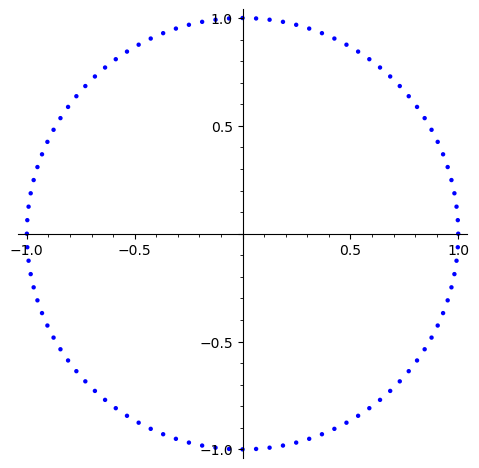

In [37]:
n = 100
point2d([(cos(x*2*pi/n),sin(x*2*pi/n)) for x in range(n)]).show(aspect_ratio=1)

In [38]:
p = point3d([(cos(x*2*pi/n),sin(x*2*pi/n),0) for x in range(n)],color='blue')
p += point3d([(cos(x*2*pi/n),0,sin(x*2*pi/n)) for x in range(n)],color='red')
p += point3d([(0,cos(x*2*pi/n),sin(x*2*pi/n)) for x in range(n)],color='green')
p.show(aspect_ratio=1)

Graphics3d Object

In [56]:
import random
from scipy.spatial import Voronoi, ConvexHull

def new_points():
    return [(random.uniform(0,1), random.uniform(0,1)) for _ in range(20)]

pts = new_points()
hull2d = ConvexHull(pts)
hull_indices = set(hull2d.vertices)

@interact
def geo_demo(mode=selector(['Nearest Neighbor', 'Voronoi', 'Convex Hull'], label='Modus')):
    global pts, hull2d, hull_indices
    hull2d = ConvexHull(pts)
    hull_indices = set(hull2d.vertices)

    inner = [pts[i] for i in range(len(pts)) if i not in hull_indices]
    outer = [pts[i] for i in hull_indices]

    p = points(inner, size=30, color='black', zorder=5)
    p += points(outer, size=30, color='blue', zorder=5)

    if mode == 'Nearest Neighbor':
        for i, (ax, ay) in enumerate(pts):
            best = min((j for j in range(len(pts)) if j != i),
                       key=lambda j: (pts[j][0]-ax)**2 + (pts[j][1]-ay)**2)
            bx, by = pts[best]
            p += arrow((ax, ay), (bx, by), color='blue', width=1, arrowsize=2)

    elif mode == 'Voronoi':
        vor = Voronoi(pts)
        for simplex in vor.ridge_vertices:
            if -1 not in simplex:
                x0, y0 = vor.vertices[simplex[0]]
                x1, y1 = vor.vertices[simplex[1]]
                p += line([(x0,y0),(x1,y1)], color='red')

    elif mode == 'Convex Hull':
        hull_pts = [pts[i] for i in hull2d.vertices]
        p += polygon(hull_pts, color='lightblue', alpha=0.5)
        p += line(hull_pts+[hull_pts[0]], color='blue', thickness=2)

    p.show(axes=False, frame=True, xmin=-0.05, xmax=1.05, ymin=-0.05, ymax=1.05)

Interactive function <function geo_demo at 0x14b2daac0> with 1 widget
  mode: Dropdown(description='Modus', options=('Nearest Neighbor', 'Voronoi', 'Convex Hull'), value='Nearest Neighbor')

In [40]:
# viele geometrische Formen wie Ikosaeder verfügbar
I = polytopes.icosahedron()
print("Ecken:", len(I.vertices()))
print("Flächen:", len(I.faces(2)))
I.plot()

Ecken: 12
Flächen: 20


Graphics3d Object

In [41]:
import random
from scipy.spatial import ConvexHull
import numpy as np

random.seed()  # system time
pts3 = [(random.uniform(-1,1), random.uniform(-1,1), random.uniform(-1,1)) for _ in range(30)]
arr3 = np.array(pts3)

hull3 = ConvexHull(arr3)
hull_idx3 = set(hull3.vertices)

p3 = point3d([pts3[i] for i in hull_idx3], size=10, color='blue')
p3 += point3d([pts3[i] for i in range(len(pts3)) if i not in hull_idx3], size=10, color='black')

for simplex in hull3.simplices:
    tri = [pts3[i] for i in simplex]
    p3 += polygon3d(tri, color='lightblue', alpha=0.3)

p3.show()

Graphics3d Object

**3D Pseudohyperebenen-Arrangement:**

[lasagne3d/example_pshyperplanes.html](lasagne3d/example_pshyperplanes.html)

[https://helenabergold.github.io/supp/3d_signotopes/nonextendable_sign48_pshyperplane.html](https://helenabergold.github.io/supp/3d_signotopes/nonextendable_sign48_pshyperplane.html)


### Arrangements in der Ebene und auf der Sphäre 

<img src="figs/apc_2019_p11.png" width="80%">
(Grafik mit GeoGebra erstellt)



* Geometrische Objekte durch Graphen repräsentieren
* Koordinaten irrelevant, nur Kombinatorik/Topologie erfasst
* "Gleichheitstest" via Graphenisomorphie
* Eigenschaften wie "Anzahl der Dreiecks-Zellen" in Graph sichtbar

<img src=figs/arrangement_graphs.png width=80%>

**Primal-Graph:** Schnittpunkte → Knoten, Bögen → Kanten

**Dual-Graph:** Zellen → Knoten, gemeinsame Kante → Kante

**Primal-Dual:** Kombination beider Sichten


## Gegenbeispiel zu Grünbaum's Vermutung aus 1970ern

Beispiel aus exhaustive computer search über alle möglichen Arrangement-Graphen

<img src=figs/arrangement.png width=50%>


[(0, 29), (0, 30), (0, 31), (1, 11), (1, 12), (1, 13), (2, 19), (2, 22), (2, 10), (3, 17), (3, 20), (3, 8), (4, 18), (4, 21), (4, 9), (5, 24), (5, 26), (5, 14), (6, 25), (6, 27), (6, 15), (7, 16), (7, 23), (7, 28), (8, 11), (8, 12), (8, 14), (9, 11), (9, 13), (9, 15), (10, 16), (10, 12), (10, 13), (11, 18), (12, 17), (13, 19), (14, 18), (14, 20), (15, 19), (15, 21), (16, 17), (16, 22), (17, 23), (18, 24), (19, 25), (20, 23), (20, 26), (21, 24), (21, 27), (22, 25), (22, 28), (23, 30), (24, 29), (25, 31), (26, 29), (26, 30), (27, 29), (27, 31), (28, 30), (28, 31)]


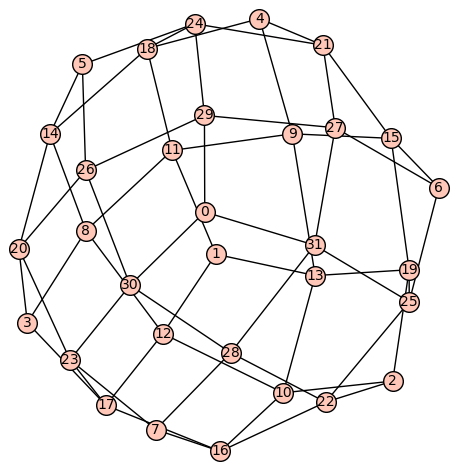

In [42]:
# Dual-Graph des Arrangements als sparse6-String
s = ":_gBca`GH`GI`HIdGeHfIbKOcJMaLNbMcNaOfPSdQTeRUdSeTfU_WYZ_VY[_XZ["
g = Graph(s)
print(g.edges(labels=False))
g.plot()

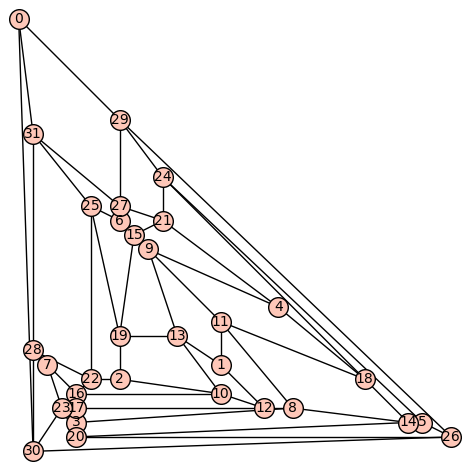

In [43]:
# Planare Darstellung (n-vertex Graph auf n x n Gitter)
g.is_planar(set_pos=1)
g.plot()

## Tutte Layout

Besseres Layout für planare Graphen: äußere Knoten auf Kreis fixiert, innere Knoten als gewichteter Schwerpunkt der Nachbarn.

([github.com/manfredscheucher/tuttedraw](https://github.com/manfredscheucher/tuttedraw))

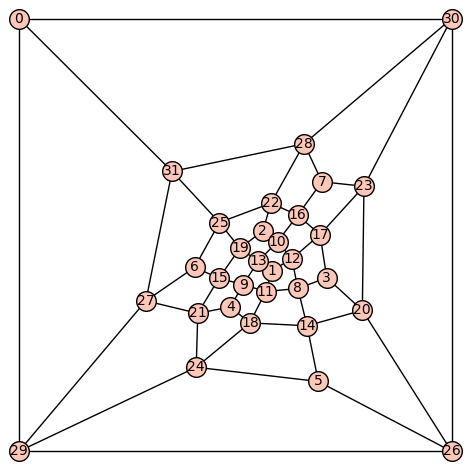

In [61]:
# https://github.com/manfredscheucher/tuttedraw/blob/main/draw.sage
def tutte_layout(G,outer_face,weights):
	V = G.vertices()
	pos = dict()
	l = len(outer_face)

	a0 = pi/l+pi/2
	for i in range(l):
		ai = a0+pi*2*i/l
		pos[outer_face[i]] = (cos(ai),sin(ai))
	
	n = len(V)
	M = zero_matrix(RR,n,n)
	b = zero_matrix(RR,n,2)

	for i in range(n):
		v = V[i]
		if v in pos:
			M[i,i] = 1
			b[i,0] = pos[v][0]
			b[i,1] = pos[v][1]
		else:
			nv = G.neighbors(v)
			s = 0
			for u in nv:
				j = V.index(u)
				wu = weights[u,v]
				s += wu
				M[i,j] = -wu
			M[i,i] = s

	sol = M.pseudoinverse()*b
	return {V[i]:sol[i] for i in range(n)}

outer_face = [v for v,_ in g.faces()[0]]
weights = {(u,v): 1 for u,v in g.edges(labels=False) for u,v in [(u,v),(v,u)]}
pos = tutte_layout(g, outer_face, weights)
g.plot(pos=pos)

---
# Graphen

* eigene native Graphbibliothek (Cython/C-Backend)  
* Schnittstellen zu **Boost Graph Library** (C++) und **NetworkX** (Python).

Knoten: ['A', 'B', 'C', 'D', 'E', 'F']
Kanten: [('A', 'B'), ('A', 'C'), ('A', 'D'), ('B', 'C'), ('B', 'E'), ('C', 'F'), ('D', 'E'), ('E', 'F')]
planar: True


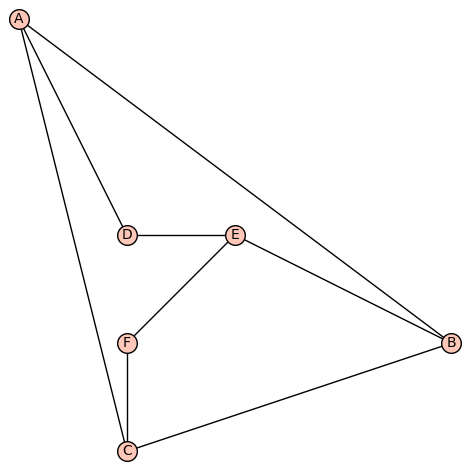

In [44]:
G = Graph({'A': ['B','C','D'], 'B': ['C','E'], 'C': ['F'], 'D': ['E'], 'E': ['F'], 'F': []})
print("Knoten:", G.vertices())
print("Kanten:", G.edges(labels=False))
print("planar:", G.is_planar(set_pos=True)) # planare Zeichnung falls vorhanden, optional
G.plot()

Chromatische Zahl: 3
Färbung: [['A', 'E'], ['B', 'D', 'F'], ['C']]


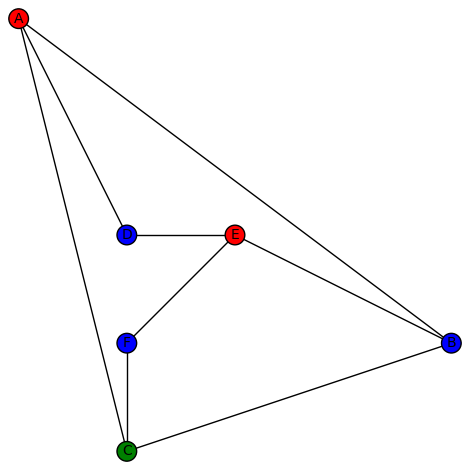

In [45]:
# Graphfärbung
chi = G.chromatic_number()
print("Chromatische Zahl:", chi)

coloring = G.coloring()
print("Färbung:", coloring)

G.plot(vertex_colors={
    'red':   coloring[0],
    'blue':  coloring[1],
    'green': coloring[2] if len(coloring) > 2 else []
})

In [46]:
# kürzeste Wege zwischen allen Knoten-Paaren
algo = choice(["BFS","Floyd-Warshall-Cython","Floyd-Warshall-Python","Dijkstra_NetworkX","Dijkstra_Boost","Johnson_Boost"])
# Liste aller Algorithmen via "G.distance_all_pairs?"

print("Algorithmus:",algo)
D = G.distance_all_pairs(algorithm=algo)
vertices = sorted(G.vertices())

print("Distanzmatrix:")
header = "    " + "  ".join(f"{v:>3}" for v in vertices)
print(header)
for u in vertices:
    row = f"{u:>3} " + "  ".join(f"{D[u][v]:>3}" for v in vertices)
    print(row)

Algorithmus: Dijkstra_Boost
Distanzmatrix:
      A    B    C    D    E    F
  A   0    1    1    1    2    2
  B   1    0    1    2    1    2
  C   1    1    0    2    2    1
  D   1    2    2    0    1    2
  E   2    1    2    1    0    1
  F   2    2    1    2    1    0


---
# Lineare Programmierung (LP)

mathematisches Verfahren zur Optimierung einer linearen Zielfunktion unter Einhaltung linearer Nebenbedingungen

**Beispiel**
$$\max\; x + y$$

$$\begin{align}
\text{s.t.} \quad 2x + y &\leq 4 \quad (1)\\
x + 2y &\leq 4 \quad (2)\\
x, y &\geq 0
\end{align}$$


In [47]:
p = MixedIntegerLinearProgram(maximization=True)
x = p.new_variable(nonnegative=True)

p.set_objective(x[1] + x[2])
p.add_constraint(2*x[1] +   x[2] <= 4)
p.add_constraint(  x[1] + 2*x[2] <= 4)

p.solve()
print(f"x = {RR(p.get_values(x[1]))}")
print(f"y = {RR(p.get_values(x[2]))}")
print(f"z (zielfunktion) = {RR(p.get_objective_value())}")

x = 1.33333333333333
y = 1.33333333333333
z (zielfunktion) = 2.66666666666667


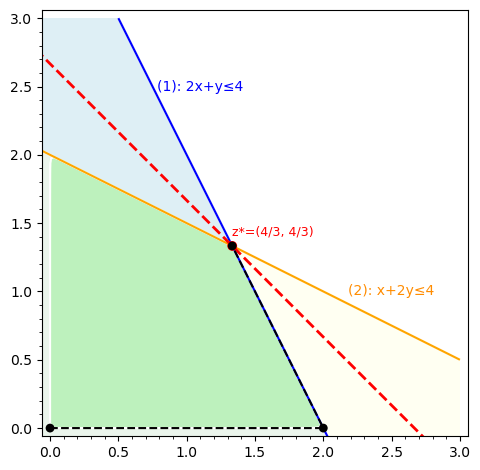

In [48]:
# graphische Darstellung der Bedingungen und Lösungsraum
x, y = var('x y')

r1 = region_plot(2*x + y <= 4, (x, -0.5, 3), (y, -0.5, 3), incol='lightblue', alpha=0.4)
r2 = region_plot(x + 2*y <= 4, (x, -0.5, 3), (y, -0.5, 3), incol='lightyellow', alpha=0.4)
r3 = region_plot([x >= 0, y >= 0, 2*x + y <= 4, x + 2*y <= 4], (x,-0.5,3), (y,-0.5,3), incol='lightgreen', alpha=0.5)

l1 = implicit_plot(2*x + y - 4, (x, -0.5, 3), (y, -0.5, 3), color='blue')
l2 = implicit_plot(x + 2*y - 4, (x, -0.5, 3), (y, -0.5, 3), color='orange')

zline   = implicit_plot(x + y - 8/3, (x, -0.5, 3), (y, -0.5, 3), color='red', linestyle='--', linewidth=2)
opt     = point((4/3, 4/3), size=50, color='red', zorder=5)
corners = points([(0,0),(2,0),(4/3,4/3)], size=40, color='black', zorder=5)
path    = line([(0,0),(2,0),(4/3,4/3)], color='black', linestyle='--', thickness=1.5)

p = r1+r2+r3+l1+l2+zline+opt+corners+path
p += text("(1): 2x+y≤4",    (1.1, 2.5),          color='blue',       fontsize=10)
p += text("(2): x+2y≤4",    (2.5, 1),          color='darkorange', fontsize=10)
p += text("z*=(4/3, 4/3)",  (4/3+0.3, 4/3+0.1), color='red',        fontsize=9)
p.show(aspect_ratio=1,xmin=0,ymin=0)

**Simplex Verfahren:** wandert entlang Ecken des zulässigen Bereichs bis Optimum erreicht:
$$(0,0) \;\to\; (2,0) \;\to\; z^* = (4/3,\, 4/3)$$

Rote Linie durch $z^*$ zeigt Optimalität bzgl. Zielfunktion $z = x+y$.

**Anmerkungen:**
- Anzahl Ecken wächst exponentiell mit Anzahl der Variablen (Dimensionen)
- **Simplex-Verfahren**:
    -  erwartungsgemäß polynomiell
    - in Praxis Millionen von Variablen und Constraints möglich
    - im worst-case exponentiell
- **Innere-Punkte-Methode**: (schwach) polynomiell
- GLPK (open) vs Gurobi (kommerziell)

---
# Mixed Integer Linear Programming (MILP)

**Beispiel: Gewinnmaximierung im Stall**

Variablen: $x_1$ = Schweine, $x_2$ = Hühner, $x_3$ = Kühe, 
— jeweils **ganzzahlig, nicht-negativ**.

$$\max \; 30 x_1 + 5 x_2 + 50 x_3$$

$$\begin{align}
\text{s.t.} \quad
\underbrace{50 x_1 + 10 x_2 + 200 x_3}_{\text{Wasser (L/Tag)}} &\leq 400 \\
\underbrace{3 x_1 + 0.5 x_2 + 8 x_3}_{\text{Futter (kg/Tag)}}  &\leq 40 \\
\underbrace{x_1 + 0.1 x_2 + x_3}_{\text{Stallplätze}}           &\leq 7
\end{align}$$

$$x_1, x_2, x_3 \in \mathbb{Z}_{\geq 0}$$

In [49]:
p = MixedIntegerLinearProgram(maximization=True)
x = p.new_variable(integer=1, nonnegative=True)

p.set_objective(30*x[1] + 5*x[2] + 50*x[3])          # max Profit (€)

p.add_constraint(50*x[1] +  10*x[2] + 200*x[3] <= 400) # Wasser (L/Tag)
p.add_constraint( 3*x[1] + 0.5*x[2] +   8*x[3] <=  40) # Futter (kg/Tag)
p.add_constraint( 1*x[1] + 0.1*x[2] +   1*x[3] <=   7) # Stallplätze

p.solve()

print(f"Schweine: {RR(p.get_values(x[1]))}")
print(f"Hühner:   {RR(p.get_values(x[2]))}")
print(f"Kühe:     {RR(p.get_values(x[3]))}")
print(f"Profit:   {RR(p.get_objective_value())}")

Schweine: 6.00000000000000
Hühner:   10.0000000000000
Kühe:     0.000000000000000
Profit:   230.000000000000


---
## Encoding & Solver-Effizienz

- Modellierung oft **straight-forward**
- Instanzen mit Integer-Variablen → **NP-schwer**
- Encoding-Entscheidungen können Laufzeit von Solver **drastisch** beeinflussen
    - gute Heuristik: wenig Variablen & Constraints 
    - **Hilfsvariablen** zur Verkleinerung (Variablen-Constraints-Tradeoff)
    - **Symmetrien** im Suchraum werden von Solvern meist *nicht* erkannt → manuell brechen
- **SAT** ist Spezialfall von MILP:
    - nur 0/1-Variablen,
    - logisches AND/OR als Summen 

---
# SAT (Boolean Satisfiability) vs IP (Integer Programming)


**SAT-Instanz in IP-Instanz umformen (straight-forward)** 

- Boolsche Variablen $x_i \in \{0,1\}$

- Boolean Constraints als Summen:
$$x_1 \lor (1-x_2) \lor x_3 \quad\Leftrightarrow\quad x_1 + (1-x_2) + x_3 \geq 1 \quad\Leftrightarrow\quad x_1 -x_2 + x_3 \geq 0$$

**IP-Instanz in SAT-Instanz umformen**:
- Summen bzw. Teilsummen mittels Indikatorvariablen beschreiben

Beispiel: $x_1+x_2+x_3+x_4$
* Teilsumme $u := x_1+x_2$
    * 3 mögliche Werte: 0, 1, oder 2 
    * 3 Indikatorvariablen "$u$ ist 0", "$u$ ist 1", "$u$ ist 2"
* Teilsumme $v := u+x_3$:
    * 4 mögliche Werte: 0 bis 3
    * 4 Indikatorvariablen
* Teilsumme $w := v+x_4$:
    *  5 mögliche Werte: 0 bis 4
    *  5 Indikatorvariablen
* Gesamt: $3+4+5$ Indikatorvariablen

## pysat
einheitliche Schnittstelle für moderne SAT-Solver wie CaDiCaL oder Kissat.

In [50]:
!sage -pip install python-sat # installiere python-sat 

In [51]:
from pysat.solvers import Cadical195

# Formel: (x1 ∨ x2) ∧ (¬x1 ∨ ¬x2)
cnf = [[1, 2],[-1, -2]]

def convert2ints(cnf): 
    return [[int(x) for x in c] for c in cnf] 
    # Sage Integers -> python int conversion
    # In Sage ist 1 kein int (so wie in python) sondern ein Integer

solver = Cadical195(bootstrap_with=convert2ints(cnf))
for model in solver.enum_models():
    print(model)

[1, -2]
[-1, 2]


## Beispiel: Ramsey-Nummer $R(3,3) = 6$

Aussage: In jeder 2-Färbung der Kanten vom vollständigen Graphen $K_6$ gibt es ein einfarbiges Dreieck.

Beweis per SAT: teste ob $R(3,3) > n$ lösbar ist.

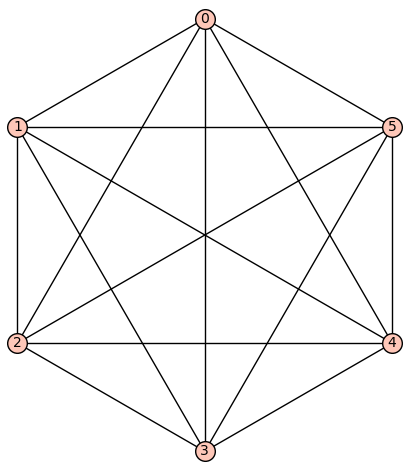

In [52]:
graphs.CompleteGraph(6).plot()

R(3,3) > 5: SAT (Färbung existiert)


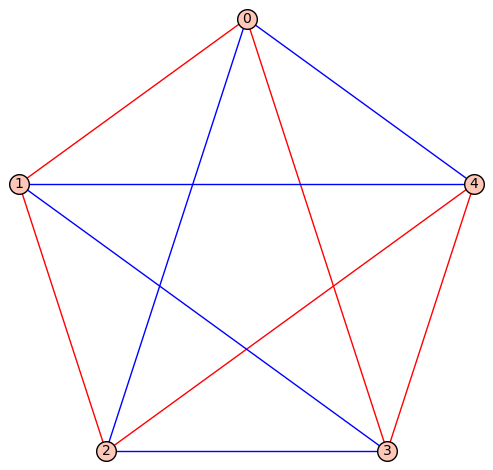

R(3,3) > 6: UNSAT


In [53]:
from itertools import combinations
from pysat.solvers import Cadical195
from pysat.formula import IDPool

def ramsey_gt(n, k, l):
    """Ist R(k,l) > n? Liefert (Modell, pool) oder None."""
    V = range(n)
    pool = IDPool()
    
    def edge_var(u,v):
        return pool.id((min(u,v),max(u,v))) # Variable codiert Kante von u nach v 

    cnf = []
    for a,b,c in combinations(V, 3):
        cnf.append([-edge_var(a,b), -edge_var(a,c), -edge_var(b,c)])
        cnf.append([+edge_var(a,b), +edge_var(a,c), +edge_var(b,c)])

    solver = Cadical195(bootstrap_with=cnf)
    if solver.solve():
        model = solver.get_model()
        red_edges  = [(u,v,0) for u,v in combinations(V,2) if  edge_var(u,v) in model]
        blue_edges = [(u,v,1) for u,v in combinations(V,2) if -edge_var(u,v) in model]
        return Graph(red_edges+blue_edges)
    else:
        return None

for n in [5, 6]:
    G = ramsey_gt(n, 3, 3)
    print(f'R(3,3) > {n}: {"SAT (Färbung existiert)" if G else "UNSAT"}')
    if G:
        G.plot(layout='circular',color_by_label={0:'red',1:'blue'}).show()

---
# SMT — Satisfiability Modulo Theories

SAT + Theorien: Arithmetik, Arrays, Bitvektoren, ...

**Anwendung:** Formale Verifikation von Algorithmen (z.B. Bubblesort)

**Beispiel**: Ist $x^2 + y^2 = 1 \land x = y \land x > 0$ erfüllbar? (Einheitskreis schneidet Gerade $y=x$)


In [54]:
!sage -pip install z3-solver # installiere z3 solver

In [55]:
from z3 import *
x, y = Reals('x y')
s = Solver()
s.add(x**2 + y**2 == 1, x == y, x > 0)
print("satisfiable:",s.check())
print("model:",s.model())

satisfiable: sat
model: [y = 0.7071067811?, x = 0.7071067811?]


---

<img src="figs/apc_circ_2018_last.png" width="70%">

Fragen? Code & Notebook: <a href="https://github.com/manfredscheucher/talk-glt26">https://github.com/manfredscheucher/talk-glt26</a>